# Power System Operations Workshop

This workshop was created for the workshop **Powering the Energy Transition: Different Pieces, One Shared Puzzle** on 2026-10-08 at the Bright Cubes office.

## Premise

Bright Cubes' LinkedIn post about the NVidia DGX Sparks has attracted a lot of attention and some customers are looking to host some of their tooling on Bright Cubes servers.
With that in mind, Bright Cubes wants to get additional NVidia DGX equipment: 10 NVidia GDX Station GB300 (1600 W peak total system power each).
However, their energy contract currently does not suffice, so they are looking to increase the capacity allocated to the contract with 16 kW.

### Your role

You are a power system operator with only one goal: bringing the energy transition to a conclusion without blackouts.
You are tasked with answering the following questions:

* Can we increase the capacity for Bright Cubes?
* If not, can we provide a compromise?

A customer request can only be safely approved if these constraints remain satisfied:

1. Given a certain prior simulation of production and consumption, no cable or transformer is allowed to exceed its set capacity. This is called a timeseries analysis.
2. If a cable breaks or is disconnected for maintenance, then there is always a different configuration of the grid available that can run the entire time series without exceeding the equipment capacities. This is called an N-1 analysis.

## Set-up

In [64]:
import power_grid_model as pgm
import power_grid_model_ds as pgm_ds
import power_grid_model_ds.visualizer as pgm_viz

# No equipment is allowed to exceed the loading limit of 100%
MAX_LOADING = 1.0

## Grid dataset

The example network is stored in `data/workshop_grid.json` (fictional grid; no real-world data was used for this). It has a 150 kV source bus, a single-loop 10.5 kV medium-voltage backbone, two compact 400 V low-voltage feeder groups, ten symmetric loads and five rooftop solar installations. Dual transformer feeds at the source and low-voltage feeders preserve alternate paths for the N-1 analysis exercise.

In [65]:
from pathlib import Path

from power_grid_model.utils import json_deserialize_from_file

input_data = json_deserialize_from_file(Path("data/workshop_grid.json"))
grid = pgm_ds.PowerGridModelInterface(input_data=input_data).create_grid_from_input_data()
grid.check_ids()

print(
    f"Loaded {len(grid.node)} nodes, {len(grid.line)} lines, "
    f"{len(grid.transformer)} transformers, {len(grid.source)} source, "
    f"{len(grid.sym_load)} symmetric loads and {len(grid.sym_gen)} solar generators."
)

Loaded 23 nodes, 21 lines, 6 transformers, 1 source, 10 symmetric loads and 5 solar generators.


### Visualize the network

Use the PGM-DS Visualizer to visualize the grid.

In [49]:
pgm_viz.visualize(grid)

### Validate data sanity

Run the PGM data validator to validate that all necessary data is set and valid.

In [66]:
from power_grid_model.validation import errors_to_string, validate_input_data

validation_errors = validate_input_data(
    input_data, calculation_type=pgm.CalculationType.power_flow, symmetric=True
)
if validation_errors:
    raise ValueError(errors_to_string(validation_errors, name="input_data", details=True))
print("Input data is valid for a symmetric power flow calculation.")

Input data is valid for a symmetric power flow calculation.


### Validate the "base scenario"

Run a power flow calculation. Check whether there are any overloaded cables.

In [67]:
import numpy as np

model = pgm.PowerGridModel(input_data)
output_data = model.calculate_power_flow(symmetric=True)

for component in (pgm.ComponentType.line, pgm.ComponentType.transformer):
    result = output_data[component]
    overloaded = result["loading"] > MAX_LOADING
    print(
        f"{component.value}: max loading {np.max(result['loading']):.1%} "
        f"(id {result['id'][np.argmax(result['loading'])]}), "
        f"overloaded ids: {result['id'][overloaded].tolist() or 'none'}"
    )

line: max loading 95.5% (id 1027), overloaded ids: none
transformer: max loading 87.3% (id 2005), overloaded ids: none


### Simulation of current state

Load in a pre-simulated batch data set and run the power flow calculation on it.
Validate that there are no overloads.

In [68]:
from power_grid_model.validation import validate_batch_data

update_data = json_deserialize_from_file(Path("data/workshop_timeseries.json"))

batch_errors = validate_batch_data(
    input_data, update_data, calculation_type=pgm.CalculationType.power_flow, symmetric=True
)
if batch_errors:
    raise ValueError(errors_to_string(batch_errors, name="update_data", details=True))

batch_output = model.calculate_power_flow(update_data=update_data, symmetric=True)
n_scenarios = batch_output[pgm.ComponentType.node].shape[0]
print(f"Ran {n_scenarios} scenarios.")

for component in (pgm.ComponentType.line, pgm.ComponentType.transformer):
    loading = batch_output[component]["loading"]
    ids = batch_output[component]["id"][0]
    peak = loading.max(axis=0)
    print(
        f"{component.value}: max loading {peak.max():.1%} (id {ids[np.argmax(peak)]}), "
        f"ids above {MAX_LOADING:.0%}: {ids[peak > MAX_LOADING].tolist() or 'none'}"
    )

Ran 1460 scenarios.
line: max loading 96.9% (id 1027), ids above 100%: none
transformer: max loading 91.1% (id 2005), ids above 100%: none


Visualize the load for the different cables and transformers over time.

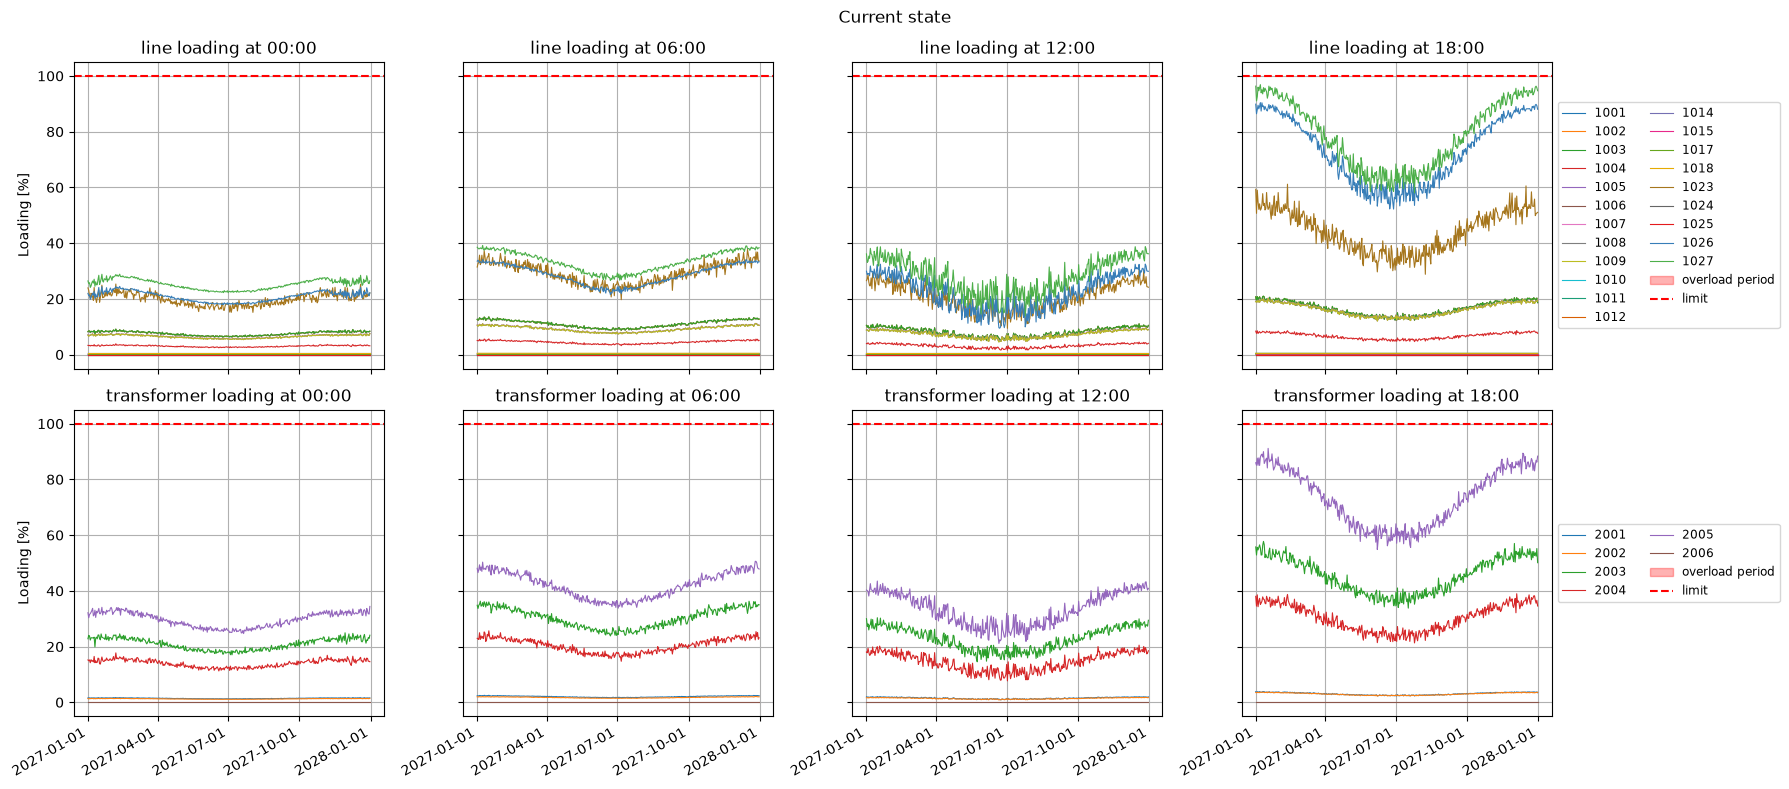

In [73]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

STEPS_PER_DAY = 4  # 6-hourly resolution
timestamps = np.datetime64("2027-01-01T00:00") + np.arange(n_scenarios) * np.timedelta64(6, "h")
days = timestamps[::STEPS_PER_DAY]


def plot_loadings(batch_output, title):
    """Plot loading per time of day, so daily cycles do not clutter the yearly trend."""
    fig, axes = plt.subplots(2, STEPS_PER_DAY, figsize=(18, 8), sharex=True, sharey="row")
    for row, component in enumerate((pgm.ComponentType.line, pgm.ComponentType.transformer)):
        loading = batch_output[component]["loading"].reshape(len(days), STEPS_PER_DAY, -1) * 100
        ids = batch_output[component]["id"][0]
        colors = list(plt.cm.tab10.colors) + list(plt.cm.Dark2.colors) + list(plt.cm.Set1.colors)
        for col in range(STEPS_PER_DAY):
            ax = axes[row, col]
            for idx, component_id in enumerate(ids):
                is_overloaded = (loading[:, :, idx] > MAX_LOADING * 100).any()
                ax.plot(
                    days,
                    loading[:, col, idx],
                    label=f"{component_id} (overloaded)" if is_overloaded else str(component_id),
                    color="black" if is_overloaded else colors[idx],
                    linewidth=1.5 if is_overloaded else 0.8,
                    zorder=3 if is_overloaded else 2,
                )
            ax.fill_between(
                days, 0, 1, where=(loading[:, col] > MAX_LOADING * 100).any(axis=1),
                color="red", alpha=0.3, transform=ax.get_xaxis_transform(), label="overload period",
            )
            ax.axhline(MAX_LOADING * 100, color="red", linestyle="--", label="limit")
            ax.set_title(f"{component.value} loading at {col * 6:02d}:00")
            ax.grid(True)
            ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        axes[row, 0].set_ylabel("Loading [%]")
        handles, labels = axes[row, -1].get_legend_handles_labels()
        axes[row, -1].legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="small", ncol=2)
    fig.autofmt_xdate()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_loadings(batch_output, "Current state")

## Bright Cubes capacity request

We now have validated the current state of the grid. But, of course, that was not the original question.

Now, Bright Cubes (with customer ID `4010`) would like to increase their allocated capacity.
Given the high demand in Bright Cubes-hosted AI tools, they want to buy 10 NVidia GDX Station GB300 (1600 W peak total system power each).
That amounts to a total of 16 kW increase in capacity.

Your task is to check whether that fits.

line: max loading 101.8% (id 1027), ids above 100%: [1027]
transformer: max loading 92.8% (id 2005), ids above 100%: none
Request does NOT fit in the grid.


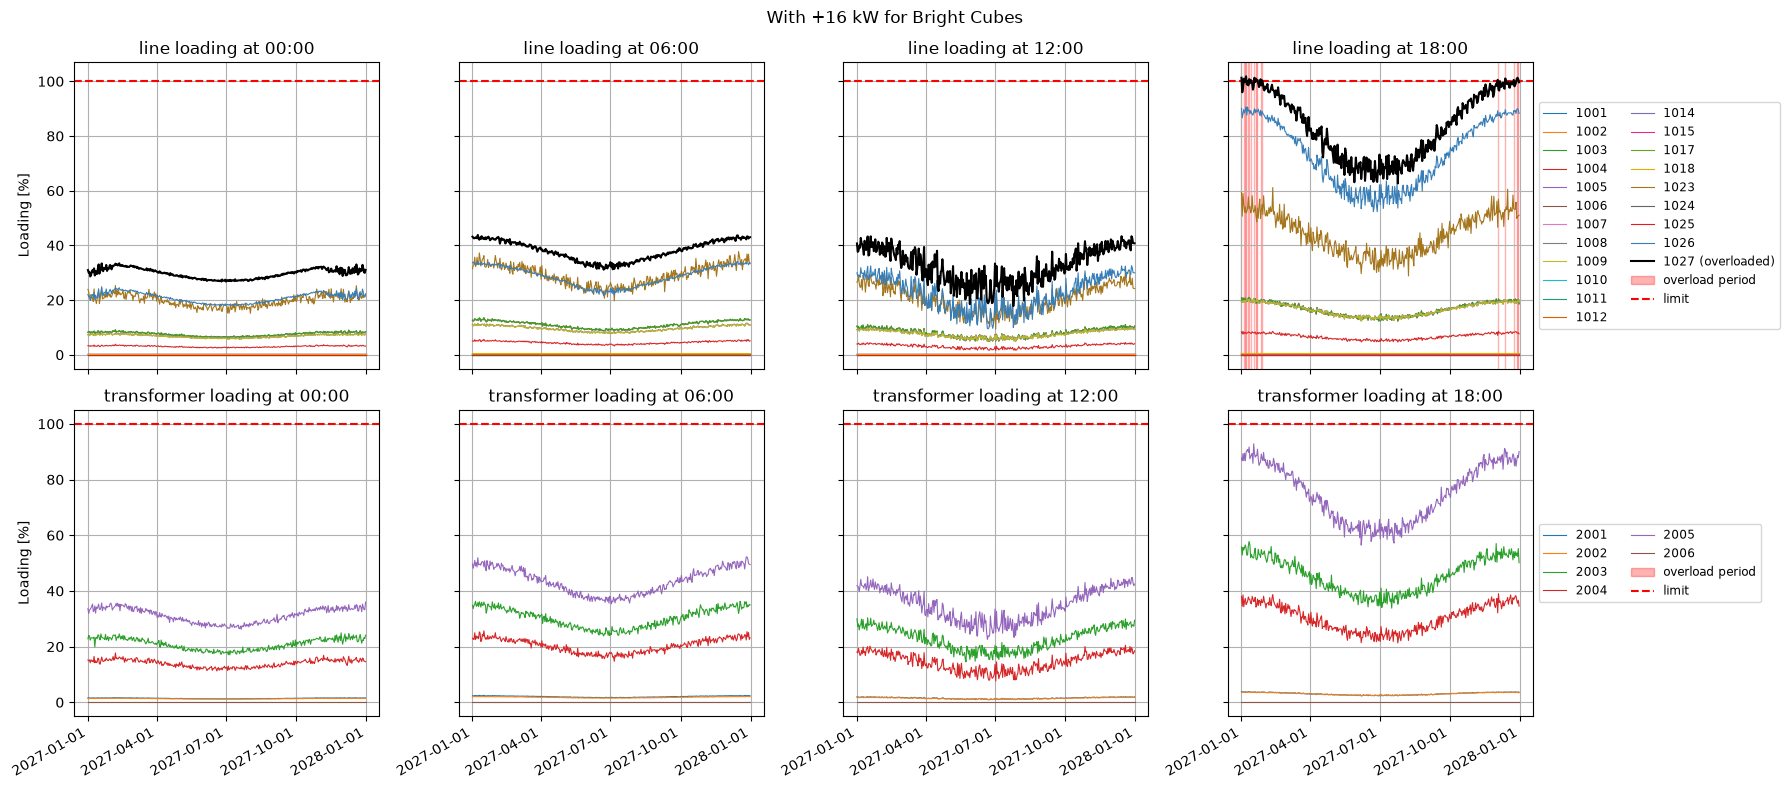

In [74]:
BRIGHT_CUBES_LOAD_ID = 4010
EXTRA_CAPACITY = 16_000.0  # W

request_update = {component: data.copy() for component, data in update_data.items()}
sym_load_update = request_update[pgm.ComponentType.sym_load]
# Worst case: the extra peak power is drawn during every time step.
sym_load_update["p_specified"][sym_load_update["id"] == BRIGHT_CUBES_LOAD_ID] += EXTRA_CAPACITY

request_output = model.calculate_power_flow(update_data=request_update, symmetric=True)

request_fits = True
for component in (pgm.ComponentType.line, pgm.ComponentType.transformer):
    loading = request_output[component]["loading"]
    ids = request_output[component]["id"][0]
    peak = loading.max(axis=0)
    overloaded = peak > MAX_LOADING
    request_fits &= not overloaded.any()
    print(
        f"{component.value}: max loading {peak.max():.1%} (id {ids[np.argmax(peak)]}), "
        f"ids above {MAX_LOADING:.0%}: {ids[overloaded].tolist() or 'none'}"
    )

print("Request fits in the grid." if request_fits else "Request does NOT fit in the grid.")
plot_loadings(request_output, f"With +{EXTRA_CAPACITY / 1000:.0f} kW for Bright Cubes")

It turns out that there now is an overloaded line during certain moments in the winter around dinner time.
Apparently, 10 NVidia DGX Station GB300's is too many.
How many can Bright Cubes buy instead?

In [ ]:
# TODO(copilot)